#  Cours 2 — Évaluation, régularisation et cross-validation
## Machine Learning Supervisé · Jour 1 

> **Dataset fil rouge :** California Housing + dataset synthétique bruité (50 features)

---

###  Objectifs du cours

| # | Objectif | Compétence |
|---|----------|-----------|
| 1 | Choisir et interpréter les métriques adaptées à la régression | C3.4 |
| 2 | Mettre en place une validation croisée robuste | C3.2 / C3.4 |
| 3 | Comprendre et appliquer la régularisation Ridge (L2) et Lasso (L1) | C3.3 |
| 4 | Comparer des modèles régularisés sur un cas concret | C3.4 |

###  Ce que vous savez déjà (Cours 1 + TP 1)
- Régression linéaire simple et multiple
- MSE et R² calculés sur les données d'entraînement
- Pourquoi un split train/test est obligatoire


---
##  Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import (LinearRegression, Ridge, Lasso,
                                   RidgeCV, LassoCV, ElasticNet)
from sklearn.model_selection import (train_test_split, KFold, StratifiedKFold,
                                      cross_val_score, cross_validate,
                                      learning_curve)
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
np.random.seed(42)

# ── Dataset fil rouge : California Housing ────────────────────────────────────
data  = fetch_california_housing(as_frame=True)
X_ca  = data.data
y_ca  = data.target
X_train, X_test, y_train, y_test = train_test_split(
    X_ca, y_ca, test_size=0.2, random_state=42
)
print(f"California Housing — train : {X_train.shape}  |  test : {X_test.shape}")

# ── Dataset bruité : 50 features dont 40 sont du bruit ───────────────────────
N, P_SIGNAL, P_BRUIT = 500, 10, 40
P_TOTAL = P_SIGNAL + P_BRUIT
np.random.seed(42)

X_bruit_all = np.random.randn(N, P_TOTAL)
true_coefs  = np.concatenate([np.random.randn(P_SIGNAL) * 2, np.zeros(P_BRUIT)])
y_bruit_all = X_bruit_all @ true_coefs + np.random.randn(N) * 1.5

cols_bruit  = [f's{i+1:02d}' for i in range(P_SIGNAL)] +               [f'b{i+1:02d}' for i in range(P_BRUIT)]
X_bruit     = pd.DataFrame(X_bruit_all, columns=cols_bruit)

X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(
    X_bruit, y_bruit_all, test_size=0.2, random_state=42
)
print(f"Dataset bruité    — train : {X_b_train.shape}  |  test : {X_b_test.shape}")
print(f"  Features signal : s01–s{P_SIGNAL:02d}  |  Features bruit : b01–b{P_BRUIT:02d}")
print(" Setup OK")


California Housing — train : (16512, 8)  |  test : (4128, 8)
Dataset bruité    — train : (400, 50)  |  test : (100, 50)
  Features signal : s01–s10  |  Features bruit : b01–b40
 Setup OK


---
## Partie 1 — Métriques d'évaluation en régression
### 1.1 Les métriques

Un bon data scientist ne choisit pas sa métrique au hasard. Chacune répond à une question différente.

| Métrique | Formule | Unité | Sensibilité outliers | Question posée |
|----------|---------|-------|---------------------|----------------|
| **MSE** | $\frac{1}{n}\sum(y-\hat{y})^2$ | (unité y)² | Très élevée | Quelle est l'erreur quadratique moyenne ? |
| **RMSE** | $\sqrt{MSE}$ | unité y | Élevée | Quelle est l'erreur typique dans l'unité de y ? |
| **MAE** | $\frac{1}{n}\sum {y-\hat{y}}$ | unité y | Modérée | Quelle est l'erreur absolue médiane ? |
| **R²** | $1 - \frac{MSE}{\text{Var}(y)}$ | sans unité ∈ (−∞, 1] | Modérée | Quelle fraction de la variance est expliquée ? |
| **R² ajusté** | $1-(1-R^2)\frac{n-1}{n-p-1}$ | sans unité | Modérée | Idem, pénalisé par le nombre de features |

>  **Règle empirique :**  
> — Si les grandes erreurs sont catastrophiques (ex : prédire une durée de vie d'avion) → **MSE / RMSE**  
> — Si toutes les erreurs se valent (ex : prédire une livraison à J+1 ou J+3) → **MAE**  
> — Pour comparer des modèles sur des datasets différents → **R²**  
> — Pour comparer des modèles avec des nombres de features différents → **R² ajusté**

---

### 1.2 Le piège du R² — trois cas où il ment


Cas 1 : R² négatif
  R² modèle nul (prédire la moyenne) : 0.0000  ← plancher
  R² modèle aléatoire                : -1.6000  ← pire que la moyenne !



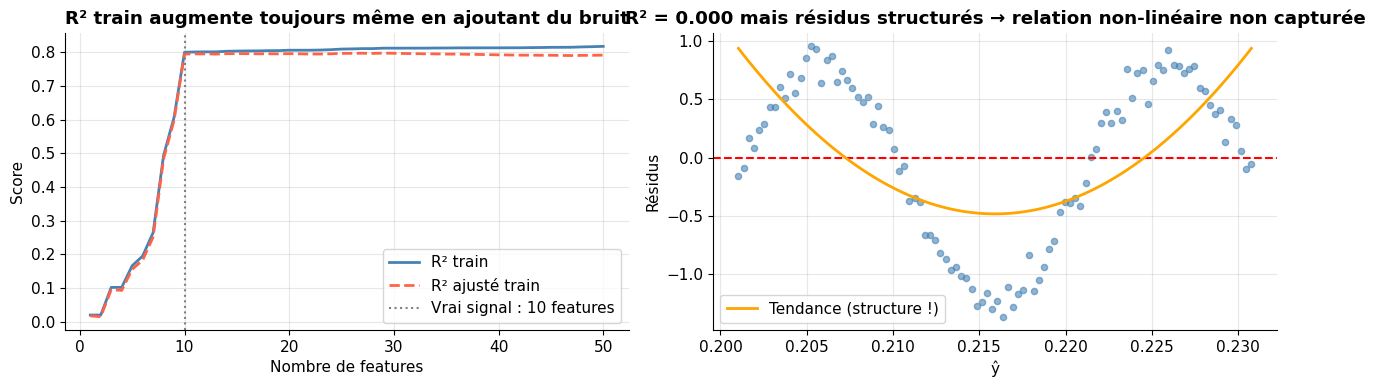

Cas 3 : même avec R² ≈ 0.6, les résidus révèlent un problème structurel.


In [3]:
# ── Cas 1 : R² peut être négatif ─────────────────────────────────────────────
#
# Un modèle pire que "prédire la moyenne" a un R² < 0.
# C'est possible en production si le modèle overfit massivement.
#

y_true   = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_moyen  = np.full(5, y_true.mean())           # Modèle nul : prédire la moyenne
y_mauvais = np.array([5.0, 1.0, 4.0, 2.0, 3.0]) # Modèle aléatoire

print("Cas 1 : R² négatif")
print(f"  R² modèle nul (prédire la moyenne) : {r2_score(y_true, y_moyen):.4f}  ← plancher")
print(f"  R² modèle aléatoire                : {r2_score(y_true, y_mauvais):.4f}  ← pire que la moyenne !")
print()

# ── Cas 2 : R² augmente mécaniquement avec le nombre de features ──────────────
#
# En OLS, ajouter une feature (même du bruit pur) ne peut qu'augmenter le R² en train.
# C'est pourquoi il faut le R² ajusté pour comparer des modèles avec p différents.
#

pipe_base = Pipeline([('sc', StandardScaler()), ('lr', LinearRegression())])
r2_scores = []
adj_r2_scores = []

for k in range(1, X_b_train.shape[1] + 1):
    Xk = X_b_train.iloc[:, :k]
    pipe_base.fit(Xk, y_b_train)
    r2 = pipe_base.score(Xk, y_b_train)
    n, p = Xk.shape
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    r2_scores.append(r2)
    adj_r2_scores.append(adj_r2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(range(1, 51), r2_scores,     'steelblue', lw=2, label='R² train')
ax.plot(range(1, 51), adj_r2_scores, 'tomato',    lw=2, ls='--', label='R² ajusté train')
ax.axvline(P_SIGNAL, color='gray', ls=':', lw=1.5, label=f'Vrai signal : {P_SIGNAL} features')
ax.set_xlabel('Nombre de features'); ax.set_ylabel('Score')
ax.set_title('R² train augmente toujours même en ajoutant du bruit', fontweight='bold')
ax.legend()

# ── Cas 3 : R² élevé mais résidus non-aléatoires ─────────────────────────────
np.random.seed(0)
x_demo = np.linspace(0, 3, 100)
y_demo = np.sin(x_demo * np.pi) + np.random.randn(100) * 0.1  # relation sinusoïdale

lr_demo = LinearRegression()
lr_demo.fit(x_demo.reshape(-1, 1), y_demo)
y_pred_demo = lr_demo.predict(x_demo.reshape(-1, 1))
res_demo    = y_demo - y_pred_demo

ax = axes[1]
ax.scatter(y_pred_demo, res_demo, s=20, alpha=0.6, color='steelblue')
ax.axhline(0, color='red', lw=1.5, ls='--')
z2 = np.polyfit(y_pred_demo, res_demo, 2)
xr = np.sort(y_pred_demo)
ax.plot(xr, np.poly1d(z2)(xr), 'orange', lw=2, label='Tendance (structure !)')
ax.set_xlabel('ŷ'); ax.set_ylabel('Résidus')
ax.set_title(f'R² = {r2_score(y_demo, y_pred_demo):.3f} mais résidus structurés → relation non-linéaire non capturée',
             fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

print("Cas 3 : même avec R² ≈ 0.6, les résidus révèlent un problème structurel.")


### 1.3 MSE vs MAE — quand choisir ?


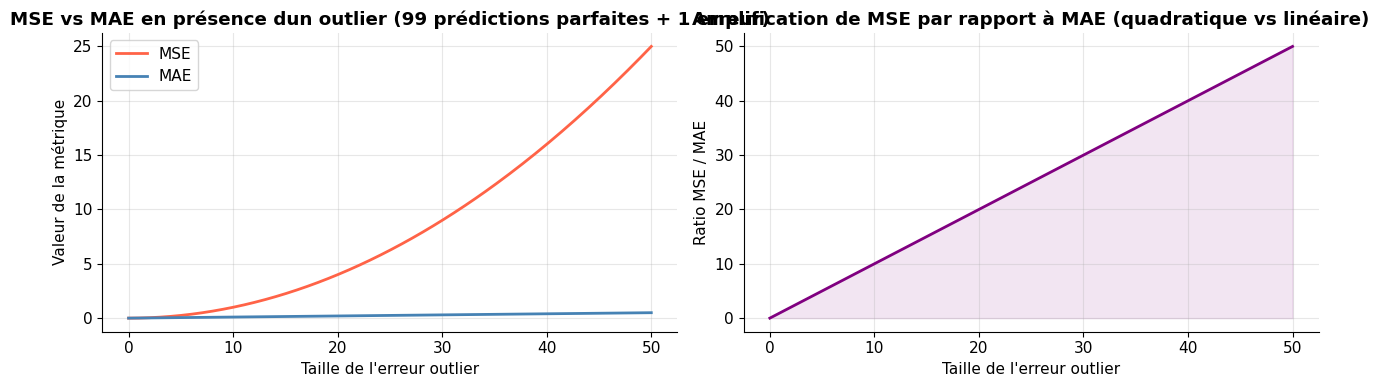

Exemple avec 1 erreur de 10 :
  MSE = 1.00   MAE = 0.10   Ratio = 10.0×
Exemple avec 1 erreur de 30 :
  MSE = 9.00   MAE = 0.30   Ratio = 30.0×


In [8]:
# ── Impact des outliers sur MSE vs MAE ───────────────────────────────────────
#
# Scénario : 99 prédictions parfaites, 1 énorme erreur.
# Comparer l'impact sur MSE et MAE.
#

n_obs = 100
y_clean = np.zeros(n_obs)          # vraies valeurs : toutes à 0
y_pred_clean = np.zeros(n_obs)     # prédictions parfaites

# Injecter un outlier de plus en plus grand
outlier_sizes = np.linspace(0, 50, 200)
mse_vals, mae_vals = [], []

for out in outlier_sizes:
    yp = y_pred_clean.copy()
    yp[-1] = out                   # une seule prédiction très mauvaise
    mse_vals.append(mean_squared_error(y_clean, yp))
    mae_vals.append(mean_absolute_error(y_clean, yp))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Courbes MSE / MAE en fonction de la taille de l'outlier
ax = axes[0]
ax.plot(outlier_sizes, mse_vals, 'tomato',    lw=2, label='MSE')
ax.plot(outlier_sizes, mae_vals, 'steelblue', lw=2, label='MAE')
ax.set_xlabel("Taille de l'erreur outlier")
ax.set_ylabel('Valeur de la métrique')
ax.set_title('MSE vs MAE en présence d''un outlier (99 prédictions parfaites + 1 erreur)', fontweight='bold')
ax.legend()

# Ratio MSE/MAE — l'amplification
ax = axes[1]
ratio = np.array(mse_vals) / (np.array(mae_vals) + 1e-9)
ax.plot(outlier_sizes, ratio, 'purple', lw=2)
ax.set_xlabel("Taille de l'erreur outlier")
ax.set_ylabel('Ratio MSE / MAE')
ax.set_title('Amplification de MSE par rapport à MAE (quadratique vs linéaire)',
             fontweight='bold')
ax.fill_between(outlier_sizes, ratio, alpha=0.1, color='purple')

plt.tight_layout()
plt.show()

# Chiffres concrets
print("Exemple avec 1 erreur de 10 :")
y_ex = y_pred_clean.copy(); y_ex[-1] = 10
print(f"  MSE = {mean_squared_error(y_clean, y_ex):.2f}   "
      f"MAE = {mean_absolute_error(y_clean, y_ex):.2f}   "
      f"Ratio = {mean_squared_error(y_clean, y_ex)/mean_absolute_error(y_clean, y_ex):.1f}×")

print("Exemple avec 1 erreur de 30 :")
y_ex[-1] = 30
print(f"  MSE = {mean_squared_error(y_clean, y_ex):.2f}   "
      f"MAE = {mean_absolute_error(y_clean, y_ex):.2f}   "
      f"Ratio = {mean_squared_error(y_clean, y_ex)/mean_absolute_error(y_clean, y_ex):.1f}×")


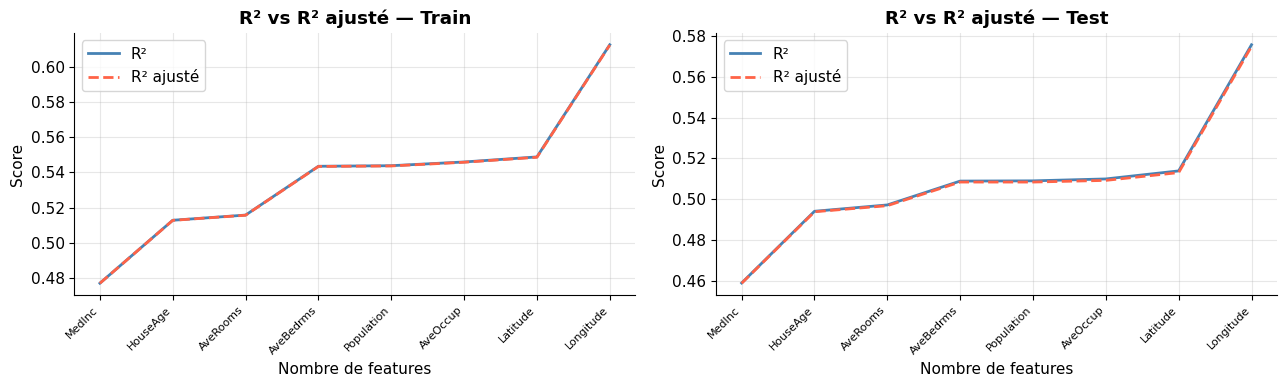

Observation clé :
  En TRAIN : R² ne peut qu'augmenter. R² ajusté peut décroître si la feature n'apporte rien.
  En TEST  : R² et R² ajusté peuvent tous deux baisser si on ajoute des features non pertinentes.


In [9]:
# ── R² ajusté vs R² brut sur California Housing ──────────────────────────────

pipe_ca = Pipeline([('sc', StandardScaler()), ('lr', LinearRegression())])
results = []

for k in range(1, X_train.shape[1] + 1):
    feat = X_train.columns[:k]
    pipe_ca.fit(X_train[feat], y_train)

    # Scores sur le TRAIN
    r2_tr  = pipe_ca.score(X_train[feat], y_train)
    n, p   = X_train[feat].shape
    adj_tr = 1 - (1 - r2_tr) * (n - 1) / (n - p - 1)

    # Scores sur le TEST (honnêtes)
    r2_te  = pipe_ca.score(X_test[feat], y_test)
    n_te, p_te = X_test[feat].shape
    adj_te = 1 - (1 - r2_te) * (n_te - 1) / (n_te - p_te - 1)

    results.append({'features': k, 'feature_name': feat[-1],
                    'R²_train': r2_tr, 'R²adj_train': adj_tr,
                    'R²_test':  r2_te, 'R²adj_test':  adj_te})

df_r = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, split in zip(axes, ['train', 'test']):
    ax.plot(df_r['features'], df_r[f'R²_{split}'],     'steelblue', lw=2, label='R²')
    ax.plot(df_r['features'], df_r[f'R²adj_{split}'],  'tomato', lw=2, ls='--', label='R² ajusté')
    ax.set_xlabel('Nombre de features'); ax.set_ylabel('Score')
    ax.set_title(f'R² vs R² ajusté — {split.capitalize()}', fontweight='bold')
    ax.legend()
    ax.set_xticks(df_r['features'])
    ax.set_xticklabels([r['feature_name'] for r in results], rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

print("Observation clé :")
print("  En TRAIN : R² ne peut qu'augmenter. R² ajusté peut décroître si la feature n'apporte rien.")
print("  En TEST  : R² et R² ajusté peuvent tous deux baisser si on ajoute des features non pertinentes.")


### 1.4 Analyse des résidus — les 4 diagnostics

Un modèle de régression suppose que les résidus sont :

1. **Centrés en 0** — pas de biais systématique
2. **Homoscédastiques** — variance constante quelle que soit ŷ
3. **Normaux** — distribution gaussienne (pour les tests statistiques)
4. **Indépendants** — pas d'autocorrélation (surtout pour les séries temporelles)

> Ces hypothèses sont nécessaires pour que les intervalles de confiance et les tests statistiques soient valides.  
> La prédiction elle-même n'en dépend pas — mais l'inférence (est-ce que β₁ est significativement différent de 0 ?) oui.


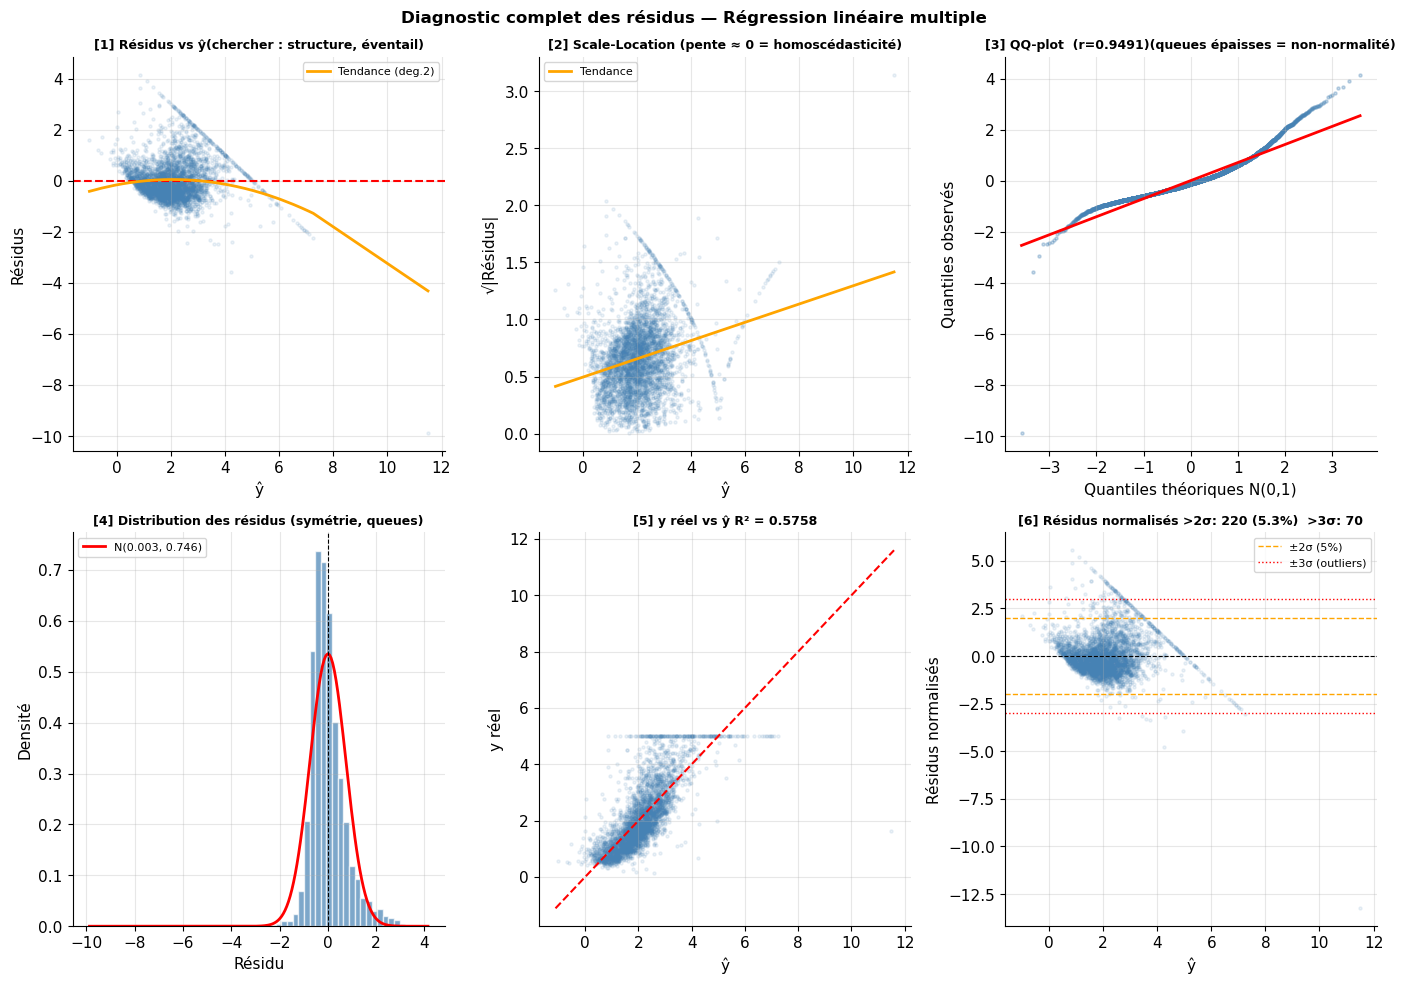

Skewness    : 0.5457  (|>0.5| = asymétrie notable)
Kurtosis    : 10.0701  (>0 = queues plus épaisses que normale)
Shapiro-Wilk: p = 1.74e-45  (Non-normal au seuil 5%)


In [10]:
# ── Les 4 diagnostics de résidus sur California Housing ──────────────────────

pipe_diag = Pipeline([('sc', StandardScaler()), ('lr', LinearRegression())])
pipe_diag.fit(X_train, y_train)
y_pred_diag = pipe_diag.predict(X_test)
res         = y_test.values - y_pred_diag

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)

# ── [1] Résidus vs ŷ ─────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_pred_diag, res, alpha=0.1, s=5, color='steelblue')
ax1.axhline(0, color='red', lw=1.5, ls='--')
z2   = np.polyfit(y_pred_diag, res, 2)
xr   = np.sort(y_pred_diag)
ax1.plot(xr, np.poly1d(z2)(xr), 'orange', lw=2, label='Tendance (deg.2)')
ax1.set_xlabel('ŷ'); ax1.set_ylabel('Résidus')
ax1.set_title('[1] Résidus vs ŷ(chercher : structure, éventail)', fontweight='bold', fontsize=9)
ax1.legend(fontsize=8)

# ── [2] √|résidus| vs ŷ  (test homoscédasticité) ─────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
sqrt_abs_res = np.sqrt(np.abs(res))
ax2.scatter(y_pred_diag, sqrt_abs_res, alpha=0.1, s=5, color='steelblue')
z_scale = np.polyfit(y_pred_diag, sqrt_abs_res, 1)
ax2.plot(xr, np.poly1d(z_scale)(xr), 'orange', lw=2, label='Tendance')
ax2.set_xlabel('ŷ'); ax2.set_ylabel('√|Résidus|')
ax2.set_title('[2] Scale-Location (pente ≈ 0 = homoscédasticité)', fontweight='bold', fontsize=9)
ax2.legend(fontsize=8)

# ── [3] QQ-plot ───────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
(osm, osr), (slope, intercept, r_qq) = stats.probplot(res)
ax3.scatter(osm, osr, s=5, alpha=0.3, color='steelblue')
ax3.plot(osm, slope * np.array(osm) + intercept, 'r-', lw=2)
ax3.set_xlabel('Quantiles théoriques N(0,1)'); ax3.set_ylabel('Quantiles observés')
ax3.set_title(f'[3] QQ-plot  (r={r_qq:.4f})(queues épaisses = non-normalité)', fontweight='bold', fontsize=9)

# ── [4] Distribution des résidus ──────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(res, bins=60, density=True, color='steelblue', edgecolor='white', alpha=0.7)
mu_r, std_r = res.mean(), res.std()
xn = np.linspace(res.min(), res.max(), 200)
ax4.plot(xn, stats.norm.pdf(xn, mu_r, std_r), 'r-', lw=2,
         label=f'N({mu_r:.3f}, {std_r:.3f})')
ax4.axvline(0, color='black', lw=0.8, ls='--')
ax4.set_xlabel('Résidu'); ax4.set_ylabel('Densité')
ax4.set_title('[4] Distribution des résidus (symétrie, queues)', fontweight='bold', fontsize=9)
ax4.legend(fontsize=8)

# ── [5] y_réel vs ŷ ───────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.scatter(y_pred_diag, y_test, alpha=0.1, s=5, color='steelblue')
lim = [min(y_pred_diag.min(), y_test.min()) - 0.1,
       max(y_pred_diag.max(), y_test.max()) + 0.1]
ax5.plot(lim, lim, 'r--', lw=1.5)
ax5.set_xlabel('ŷ'); ax5.set_ylabel('y réel')
ax5.set_title(f'[5] y réel vs ŷ R² = {r2_score(y_test, y_pred_diag):.4f}', fontweight='bold', fontsize=9)

# ── [6] Résidus normalisés (levier) ───────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
res_norm = (res - res.mean()) / res.std()
ax6.scatter(y_pred_diag, res_norm, alpha=0.1, s=5, color='steelblue')
ax6.axhline(0,   color='black', lw=0.8, ls='--')
ax6.axhline( 2,  color='orange', lw=1, ls='--', label='±2σ (5%)')
ax6.axhline(-2,  color='orange', lw=1, ls='--')
ax6.axhline( 3,  color='red',    lw=1, ls=':',  label='±3σ (outliers)')
ax6.axhline(-3,  color='red',    lw=1, ls=':')
n_out2 = np.sum(np.abs(res_norm) > 2)
n_out3 = np.sum(np.abs(res_norm) > 3)
ax6.set_xlabel('ŷ'); ax6.set_ylabel('Résidus normalisés')
ax6.set_title(f'[6] Résidus normalisés >2σ: {n_out2} ({n_out2/len(res)*100:.1f}%)  >3σ: {n_out3}',
              fontweight='bold', fontsize=9)
ax6.legend(fontsize=8)

plt.suptitle('Diagnostic complet des résidus — Régression linéaire multiple',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Stats
skew = stats.skew(res)
kurt = stats.kurtosis(res)
_, p_shapiro = stats.shapiro(res[:5000])  # shapiro sur max 5000
print(f"Skewness    : {skew:.4f}  (|>0.5| = asymétrie notable)")
print(f"Kurtosis    : {kurt:.4f}  (>0 = queues plus épaisses que normale)")
print(f"Shapiro-Wilk: p = {p_shapiro:.2e}  ({'Non-normal' if p_shapiro < 0.05 else 'Normal'} au seuil 5%)")


---
## Partie 2 — Validation croisée
### 2.1 Le problème d'un seul split

Un seul split 80/20 donne **une seule** estimation de la performance.  
Cette estimation dépend de la façon dont les données sont réparties.

> **Démonstration :** changer `random_state` dans `train_test_split` peut faire varier  
> le RMSE de manière significative — parfois plus que la différence entre deux modèles.


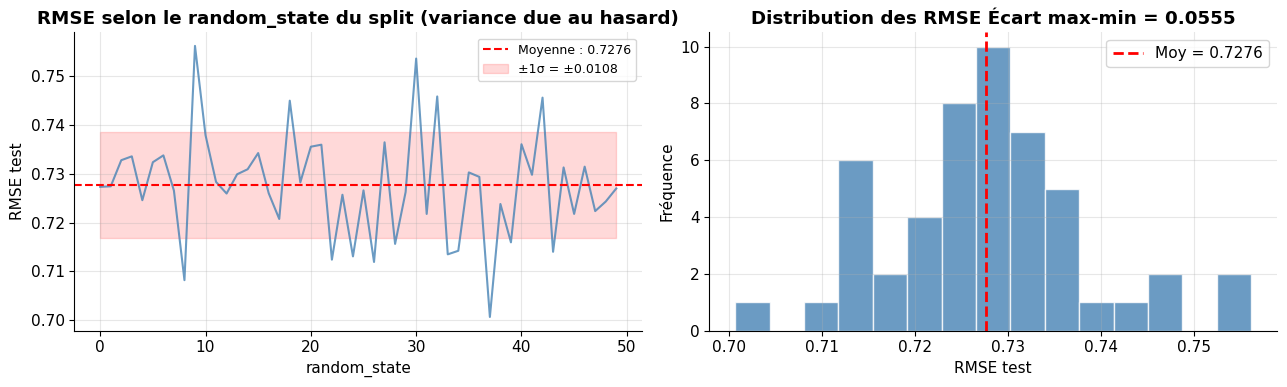

Sur 50 splits différents :
  RMSE min : 0.7007   RMSE max : 0.7562
  Écart    : 0.0555
  → Un seul split peut surestimer ou sous-estimer la performance de 7.6%


In [11]:
# ── Variance d'un seul split selon le random_state ───────────────────────────

rmse_by_seed = []
r2_by_seed   = []
seeds = range(50)

for seed in seeds:
    Xtr, Xte, ytr, yte = train_test_split(X_ca, y_ca, test_size=0.2, random_state=seed)
    pipe = Pipeline([('sc', StandardScaler()), ('lr', LinearRegression())])
    pipe.fit(Xtr, ytr)
    yp = pipe.predict(Xte)
    rmse_by_seed.append(np.sqrt(mean_squared_error(yte, yp)))
    r2_by_seed.append(r2_score(yte, yp))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(seeds, rmse_by_seed, 'steelblue', lw=1.5, alpha=0.8)
ax.axhline(np.mean(rmse_by_seed), color='red', lw=1.5, ls='--',
           label=f'Moyenne : {np.mean(rmse_by_seed):.4f}')
ax.fill_between(seeds,
                np.mean(rmse_by_seed) - np.std(rmse_by_seed),
                np.mean(rmse_by_seed) + np.std(rmse_by_seed),
                alpha=0.15, color='red', label=f'±1σ = ±{np.std(rmse_by_seed):.4f}')
ax.set_xlabel('random_state'); ax.set_ylabel('RMSE test')
ax.set_title('RMSE selon le random_state du split (variance due au hasard)',
             fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(rmse_by_seed, bins=15, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(np.mean(rmse_by_seed), color='red', lw=2, ls='--',
           label=f'Moy = {np.mean(rmse_by_seed):.4f}')
ax.set_xlabel('RMSE test'); ax.set_ylabel('Fréquence')
ax.set_title(f'Distribution des RMSE Écart max-min = {max(rmse_by_seed)-min(rmse_by_seed):.4f}',
             fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Sur 50 splits différents :")
print(f"  RMSE min : {min(rmse_by_seed):.4f}   RMSE max : {max(rmse_by_seed):.4f}")
print(f"  Écart    : {max(rmse_by_seed) - min(rmse_by_seed):.4f}")
print(f"  → Un seul split peut surestimer ou sous-estimer la performance de {(max(rmse_by_seed)-min(rmse_by_seed))/np.mean(rmse_by_seed)*100:.1f}%")


### 2.2 K-Fold Cross-Validation

La cross-validation résout ce problème en **moyennant sur plusieurs splits**.

**Principe du K-Fold :**

```
Dataset complet
│
├── Fold 1 : [TEST  | train | train | train | train]
├── Fold 2 : [train | TEST  | train | train | train]
├── Fold 3 : [train | train | TEST  | train | train]
├── Fold 4 : [train | train | train | TEST  | train]
└── Fold 5 : [train | train | train | train | TEST ]
```

À chaque fold : entraîner sur 4 parties, évaluer sur la 5e.  
Score final = **moyenne** des 5 scores ± **écart-type** (incertitude).

**Choix de K :**

| K | Avantage | Inconvénient | Recommandé pour |
|---|----------|-------------|-----------------|
| 5 | Rapide | Variance un peu plus élevée | Datasets moyens et grands |
| 10 | Bonne estimation | Plus lent | Standard industrie |
| n (LOOCV) | Variance minimale | Très lent, biais élevé | Petits datasets (< 100) |


In [12]:
# ── K-Fold Cross-Validation sur California Housing ───────────────────────────

pipe_cv = Pipeline([('sc', StandardScaler()), ('lr', LinearRegression())])

# cross_val_score : version simple
cv5_rmse  = np.sqrt(-cross_val_score(pipe_cv, X_ca, y_ca,
                                      cv=5, scoring='neg_mean_squared_error'))
cv10_rmse = np.sqrt(-cross_val_score(pipe_cv, X_ca, y_ca,
                                      cv=10, scoring='neg_mean_squared_error'))

print("Cross-validation sur California Housing :")
print()
print(f"  5-Fold  CV — RMSE par fold : {[f'{x:.4f}' for x in cv5_rmse]}")
print(f"               Moyenne ± σ   : {cv5_rmse.mean():.4f} ± {cv5_rmse.std():.4f}")
print()
print(f"  10-Fold CV — RMSE par fold : {[f'{x:.4f}' for x in cv10_rmse]}")
print(f"               Moyenne ± σ   : {cv10_rmse.mean():.4f} ± {cv10_rmse.std():.4f}")
print()
print(f"  Split unique (random_state=42) : {np.sqrt(mean_squared_error(y_test, pipe_cv.fit(X_train, y_train).predict(X_test))):.4f}")
print()
print("→ La CV donne une estimation plus fiable et quantifie l'incertitude.")


Cross-validation sur California Housing :

  5-Fold  CV — RMSE par fold : ['0.6963', '0.7890', '0.8039', '0.7370', '0.7033']
               Moyenne ± σ   : 0.7459 ± 0.0437

  10-Fold CV — RMSE par fold : ['0.6994', '0.6583', '0.9415', '0.6252', '0.8649', '0.7279', '0.5366', '0.8794', '0.8019', '0.5723']
               Moyenne ± σ   : 0.7307 ± 0.1303

  Split unique (random_state=42) : 0.7456

→ La CV donne une estimation plus fiable et quantifie l'incertitude.


Résultats cross_validate (10-fold) :
 fold  RMSE_train  RMSE_test  R2_train  R2_test  temps_fit
    1      0.7300     0.6994    0.6111   0.4825     0.0216
    2      0.7319     0.6583    0.5918   0.6142     0.0141
    3      0.6975     0.9415    0.6252   0.4227     0.0122
    4      0.7347     0.6252    0.6133   0.4818     0.0341
    5      0.7075     0.8649    0.6059   0.5571     0.0092
    6      0.7242     0.7279    0.6108   0.5413     0.0315
    7      0.7422     0.5366    0.5962   0.4750     0.0209
    8      0.7079     0.8794    0.6193   0.4584     0.0188
    9      0.7153     0.8019    0.5915   0.4818     0.0170
   10      0.7395     0.5723    0.5987   0.5953     0.0160

  RMSE train moyen : 0.7231 ± 0.0152
  RMSE test  moyen : 0.7307 ± 0.1373
  Gap biais        : 0.0077
  → Gap modéré = underfitting léger (le modèle linéaire manque de flexibilité)


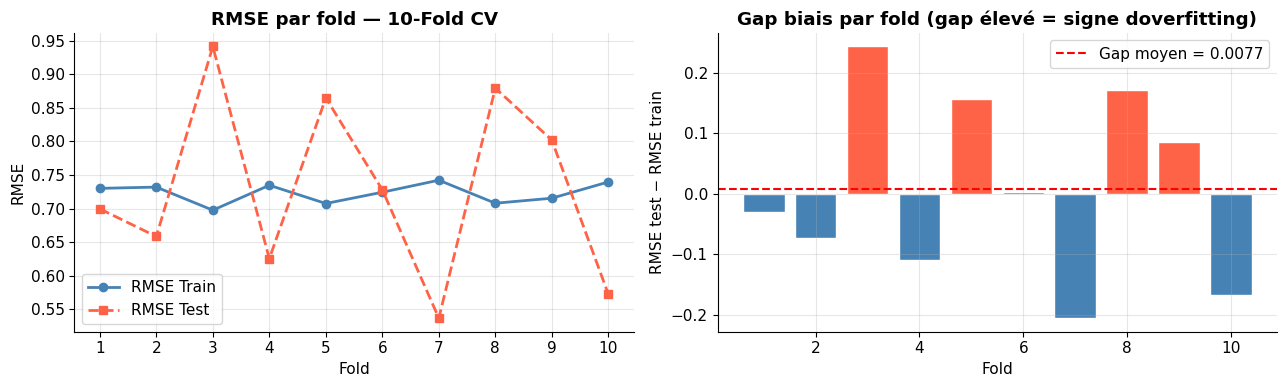

In [15]:
# ── cross_validate : version avancée (train + test + temps) ──────────────────

pipe_cv2 = Pipeline([('sc', StandardScaler()), ('lr', LinearRegression())])

cv_results = cross_validate(
    pipe_cv2, X_ca, y_ca,
    cv      = 10,
    scoring = {'rmse': 'neg_root_mean_squared_error',
               'r2':   'r2',
               'mae':  'neg_mean_absolute_error'},
    return_train_score = True,   # ← récupérer aussi les scores d'entraînement
)

df_cv = pd.DataFrame({
    'fold':       range(1, 11),
    'RMSE_train': -cv_results['train_rmse'],
    'RMSE_test':  -cv_results['test_rmse'],
    'R2_train':    cv_results['train_r2'],
    'R2_test':     cv_results['test_r2'],
    'temps_fit':   cv_results['fit_time'],
})

print("Résultats cross_validate (10-fold) :")
print(df_cv.round(4).to_string(index=False))
print()
print(f"  RMSE train moyen : {df_cv['RMSE_train'].mean():.4f} ± {df_cv['RMSE_train'].std():.4f}")
print(f"  RMSE test  moyen : {df_cv['RMSE_test'].mean():.4f} ± {df_cv['RMSE_test'].std():.4f}")
print(f"  Gap biais        : {df_cv['RMSE_test'].mean() - df_cv['RMSE_train'].mean():.4f}")
print(f"  → Gap modéré = underfitting léger (le modèle linéaire manque de flexibilité)")

# Visualiser
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
x_folds = df_cv['fold']
ax.plot(x_folds, df_cv['RMSE_train'], 'o-', color='steelblue', lw=2, label='RMSE Train')
ax.plot(x_folds, df_cv['RMSE_test'],  's--', color='tomato',   lw=2, label='RMSE Test')
ax.set_xlabel('Fold'); ax.set_ylabel('RMSE')
ax.set_title('RMSE par fold — 10-Fold CV', fontweight='bold')
ax.set_xticks(x_folds); ax.legend()

ax = axes[1]
gap = df_cv['RMSE_test'] - df_cv['RMSE_train']
ax.bar(x_folds, gap, color=['tomato' if g > 0.05 else 'steelblue' for g in gap],
       edgecolor='white')
ax.axhline(gap.mean(), color='red', ls='--', lw=1.5, label=f'Gap moyen = {gap.mean():.4f}')
ax.set_xlabel('Fold'); ax.set_ylabel('RMSE test − RMSE train')
ax.set_title('Gap biais par fold (gap élevé = signe d''overfitting)', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()


### 2.3 Quand utiliser quoi ?

```
Évaluer un seul modèle
  → cross_val_score(cv=5 ou 10, scoring='neg_root_mean_squared_error')

Comparer train vs test + métriques multiples
  → cross_validate(..., return_train_score=True)

Optimiser les hyperparamètres (alpha de Ridge/Lasso)
  → RidgeCV / LassoCV  (voir Partie 3)
  → GridSearchCV / RandomizedSearchCV

Dataset très petit (< 200 obs.)
  → LOOCV : LeaveOneOut() ou cv=n_samples

Données temporelles
  → TimeSeriesSplit (jamais mélanger passé et futur !)
```

>  **Règle d'or : le StandardScaler fait partie du fold.**  
> Il doit être fitté dans chaque fold d'entraînement, pas sur tout le dataset.  
> Utiliser un **Pipeline** garantit cela automatiquement.


In [ ]:
# ── Démonstration du data leakage dans la CV ─────────────────────────────────
#
# Comparer les estimations de RMSE avec et sans Pipeline.
# Avec un scaler hors Pipeline, il y a une fuite de l'information des folds de test.
#

kf = KFold(n_splits=10, shuffle=True, random_state=42)

# ❌ MAUVAISE PRATIQUE : scaler fitté sur tout X avant la CV
scaler_bad = StandardScaler()
X_ca_scaled_bad = scaler_bad.fit_transform(X_ca)   # fuite !
rmse_bad = np.sqrt(-cross_val_score(
    LinearRegression(), X_ca_scaled_bad, y_ca,
    cv=kf, scoring='neg_mean_squared_error'
))

# ✅ BONNE PRATIQUE : scaler dans le Pipeline, fitté à chaque fold
pipe_good = Pipeline([('sc', StandardScaler()), ('lr', LinearRegression())])
rmse_good = np.sqrt(-cross_val_score(
    pipe_good, X_ca, y_ca,
    cv=kf, scoring='neg_mean_squared_error'
))

print("Comparaison scaler hors Pipeline vs dans Pipeline :")
print(f"  ❌ Scaler avant CV (data leakage) : {rmse_bad.mean():.6f} ± {rmse_bad.std():.6f}")
print(f"  ✅ Pipeline (correct)             : {rmse_good.mean():.6f} ± {rmse_good.std():.6f}")
print(f"  Différence                         : {abs(rmse_bad.mean() - rmse_good.mean()):.6f}")
print()
print("→ Sur un grand dataset homogène, la différence est minime (les statistiques")
print("  de chaque fold ≈ statistiques globales).")
print("→ Sur un PETIT dataset ou un dataset très hétérogène, la différence peut être")
print("  significative et invalider la sélection de modèle.")


---
## Partie 3 — Régularisation Ridge (L2) et Lasso (L1)
### 3.1 Le problème : overfitting avec beaucoup de features

Quand on a trop de features (ou des features corrélées), la régression OLS donne des  
coefficients **instables et de grande amplitude**. Ils mémorisent le bruit du train.

**Idée de la régularisation :** ajouter une **pénalité** sur la taille des coefficients  
dans la fonction coût. On force le modèle à garder des coefficients petits (= moins mémorisation).

$$\text{Coût régularisé} = \underbrace{\frac{1}{n}\sum(y-\hat{y})^2}_{\text{erreur}} + \underbrace{\lambda \cdot \text{Pénalité}(\beta)}_{\text{régularisation}}$$

Le paramètre $\lambda$ (ou `alpha` dans sklearn) contrôle le **compromis** :
- $\lambda = 0$ → pas de régularisation = OLS
- $\lambda \to \infty$ → tous les coefficients → 0 (modèle nul)
- **Valeur optimale** → à trouver par cross-validation

---

### 3.2 Ridge — régularisation L2

$$\text{Coût Ridge} = \frac{1}{n}\sum(y-\hat{y})^2 + \lambda \sum_{j=1}^{p} \beta_j^2$$

La pénalité L2 **shrink** tous les coefficients vers 0 sans les annuler.  
Elle est particulièrement efficace quand toutes les features contribuent un peu.


In [ ]:
# ── Ridge : visualiser le shrinkage des coefficients ─────────────────────────
#
# On entraîne Ridge sur le dataset bruité (50 features, 10 signal + 40 bruit)
# pour différentes valeurs d'alpha et on observe comment les coefficients changent.
#

alphas = np.logspace(-3, 4, 80)   # de 0.001 à 10000

coefs_ridge = []
rmse_train_ridge = []
rmse_test_ridge  = []

scaler_b = StandardScaler()
X_b_tr_s = scaler_b.fit_transform(X_b_train)
X_b_te_s = scaler_b.transform(X_b_test)

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_b_tr_s, y_b_train)
    coefs_ridge.append(ridge.coef_.copy())

    yp_tr = ridge.predict(X_b_tr_s)
    yp_te = ridge.predict(X_b_te_s)
    rmse_train_ridge.append(np.sqrt(mean_squared_error(y_b_train, yp_tr)))
    rmse_test_ridge.append(np.sqrt(mean_squared_error(y_b_test,  yp_te)))

coefs_ridge = np.array(coefs_ridge)  # shape: (n_alphas, 50)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── [1] Chemin de régularisation Ridge ───────────────────────────────────────
ax = axes[0]
# Features signal en bleu, features bruit en gris
for j in range(coefs_ridge.shape[1]):
    color = 'steelblue' if j < P_SIGNAL else '#CCCCCC'
    lw    = 1.5         if j < P_SIGNAL else 0.5
    alpha_line = 0.9    if j < P_SIGNAL else 0.3
    ax.semilogx(alphas, coefs_ridge[:, j], color=color, lw=lw, alpha=alpha_line)

ax.axvline(1, color='gray', ls=':', lw=1)
ax.set_xlabel('alpha (log scale)'); ax.set_ylabel('Valeur du coefficient')
ax.set_title('Chemin de régularisation Ridge
(bleu = signal, gris = bruit)',
             fontweight='bold', fontsize=10)

# Ajouter légende manuelle
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], color='steelblue', lw=2, label=f'Features signal (s01–s{P_SIGNAL:02d})'),
    Line2D([0], [0], color='#CCCCCC',   lw=1, label=f'Features bruit  (b01–b{P_BRUIT:02d})'),
]
ax.legend(handles=legend_elems, fontsize=8)

# ── [2] RMSE train vs test ────────────────────────────────────────────────────
ax = axes[1]
ax.semilogx(alphas, rmse_train_ridge, 'steelblue', lw=2, label='RMSE Train')
ax.semilogx(alphas, rmse_test_ridge,  'tomato',    lw=2, ls='--', label='RMSE Test')
best_alpha_idx = np.argmin(rmse_test_ridge)
best_alpha     = alphas[best_alpha_idx]
ax.axvline(best_alpha, color='green', ls=':', lw=1.5,
           label=f'Optimal ≈ {best_alpha:.2f}')
ax.set_xlabel('alpha (log scale)'); ax.set_ylabel('RMSE')
ax.set_title('RMSE en fonction d'alpha
(min test = alpha optimal)',
             fontweight='bold', fontsize=10)
ax.legend(fontsize=8)

# ── [3] Norme des coefficients ───────────────────────────────────────────────
ax = axes[2]
norm_coefs = np.linalg.norm(coefs_ridge, axis=1)
ax.semilogx(alphas, norm_coefs, 'purple', lw=2)
ax.axvline(best_alpha, color='green', ls=':', lw=1.5, label=f'alpha optimal ≈ {best_alpha:.2f}')
ax.set_xlabel('alpha (log scale)'); ax.set_ylabel('‖β‖₂ (norme L2)')
ax.set_title('Shrinkage de la norme L2
(plus alpha grand = plus petits coefficients)',
             fontweight='bold', fontsize=10)
ax.legend(fontsize=8)

plt.suptitle('Ridge — Comportement selon alpha', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Alpha optimal (min RMSE test) : {best_alpha:.4f}")
print(f"RMSE test minimal (Ridge)     : {min(rmse_test_ridge):.4f}")
print(f"RMSE test OLS (alpha→0)       : {rmse_test_ridge[0]:.4f}")


### 3.3 Lasso — régularisation L1

$$\text{Coût Lasso} = \frac{1}{n}\sum(y-\hat{y})^2 + \lambda \sum_{j=1}^{p} |\beta_j|$$

La pénalité L1 force certains coefficients à exactement **zéro** — sélection automatique de variables.  
C'est la propriété la plus importante et la plus utile de Lasso.

**Pourquoi L1 annule mais pas L2 ?**  
La géométrie de la contrainte L1 (losange) a des coins sur les axes — l'optimum tombe souvent sur un coin, où $\beta_j = 0$.  
La contrainte L2 (sphère) est lisse — l'optimum ne tombe jamais exactement sur les axes.


In [ ]:
# ── Lasso : sélection de variables ────────────────────────────────────────────

coefs_lasso = []
rmse_train_lasso = []
rmse_test_lasso  = []
n_nonzero = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_b_tr_s, y_b_train)
    coefs_lasso.append(lasso.coef_.copy())
    n_nonzero.append(np.sum(lasso.coef_ != 0))

    yp_tr = lasso.predict(X_b_tr_s)
    yp_te = lasso.predict(X_b_te_s)
    rmse_train_lasso.append(np.sqrt(mean_squared_error(y_b_train, yp_tr)))
    rmse_test_lasso.append(np.sqrt(mean_squared_error(y_b_test,  yp_te)))

coefs_lasso = np.array(coefs_lasso)
best_alpha_lasso_idx = np.argmin(rmse_test_lasso)
best_alpha_lasso     = alphas[best_alpha_lasso_idx]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── [1] Chemin Lasso ──────────────────────────────────────────────────────────
ax = axes[0]
for j in range(coefs_lasso.shape[1]):
    color = 'steelblue' if j < P_SIGNAL else '#CCCCCC'
    lw    = 1.5         if j < P_SIGNAL else 0.5
    alpha_line = 0.9    if j < P_SIGNAL else 0.3
    ax.semilogx(alphas, coefs_lasso[:, j], color=color, lw=lw, alpha=alpha_line)

ax.axvline(best_alpha_lasso, color='green', ls=':', lw=1.5,
           label=f'Optimal ≈ {best_alpha_lasso:.4f}')
ax.set_xlabel('alpha (log scale)'); ax.set_ylabel('Valeur du coefficient')
ax.set_title('Chemin de régularisation Lasso(annulation exacte des features bruit)',
             fontweight='bold', fontsize=10)
ax.legend(handles=legend_elems + [Line2D([0],[0], color='green', ls=':', lw=1.5,
          label=f'Optimal ≈ {best_alpha_lasso:.4f}')], fontsize=8)

# ── [2] RMSE train vs test Lasso ──────────────────────────────────────────────
ax = axes[1]
ax.semilogx(alphas, rmse_train_lasso, 'steelblue', lw=2, label='RMSE Train')
ax.semilogx(alphas, rmse_test_lasso,  'tomato',    lw=2, ls='--', label='RMSE Test')
ax.axvline(best_alpha_lasso, color='green', ls=':', lw=1.5,
           label=f'Optimal ≈ {best_alpha_lasso:.4f}')
ax.set_xlabel('alpha (log scale)'); ax.set_ylabel('RMSE')
ax.set_title('RMSE Lasso en fonction d'alpha', fontweight='bold', fontsize=10)
ax.legend(fontsize=8)

# ── [3] Nombre de features non-nulles ─────────────────────────────────────────
ax = axes[2]
ax.semilogx(alphas, n_nonzero, 'purple', lw=2)
ax.axvline(best_alpha_lasso, color='green', ls=':', lw=1.5)
ax.axhline(P_SIGNAL, color='orange', ls='--', lw=1.5,
           label=f'Vrai signal : {P_SIGNAL} features')
ax.set_xlabel('alpha (log scale)'); ax.set_ylabel('Nb features non-nulles')
ax.set_title('Sélection de variables Lasso
(alpha optimal ≈ vrai signal)',
             fontweight='bold', fontsize=10)
ax.legend(fontsize=8)

plt.suptitle('Lasso — Comportement selon alpha', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Alpha optimal Lasso (min RMSE test) : {best_alpha_lasso:.4f}")
print(f"Nb features non-nulles à cet alpha   : {n_nonzero[best_alpha_lasso_idx]}")
print(f"Vrai nombre de features signal        : {P_SIGNAL}")


### 3.4 RidgeCV et LassoCV — trouver alpha par cross-validation

En pratique, on ne teste pas les alphas à la main.  
`RidgeCV` et `LassoCV` intègrent la cross-validation directement dans l'entraînement.


In [ ]:
# ── RidgeCV et LassoCV — sélection automatique d'alpha ───────────────────────

alphas_cv = np.logspace(-3, 4, 100)

# RidgeCV : utilise leave-one-out CV par défaut (rapide et exact pour Ridge)
ridge_cv = Pipeline([
    ('sc',  StandardScaler()),
    ('reg', RidgeCV(alphas=alphas_cv, cv=10)),
])
ridge_cv.fit(X_b_train, y_b_train)
best_ridge_alpha = ridge_cv.named_steps['reg'].alpha_

# LassoCV : utilise K-Fold CV (plus lent mais nécessaire pour Lasso)
lasso_cv = Pipeline([
    ('sc',  StandardScaler()),
    ('reg', LassoCV(alphas=alphas_cv, cv=10, max_iter=10000, random_state=42)),
])
lasso_cv.fit(X_b_train, y_b_train)
best_lasso_alpha = lasso_cv.named_steps['reg'].alpha_

# OLS pour comparaison
ols = Pipeline([('sc', StandardScaler()), ('reg', LinearRegression())])
ols.fit(X_b_train, y_b_train)

# Métriques sur le test
models = {
    'OLS (sans régularisation)': ols,
    f'Ridge  (alpha={best_ridge_alpha:.4f})': ridge_cv,
    f'Lasso  (alpha={best_lasso_alpha:.4f})': lasso_cv,
}

print("=" * 65)
print(f"  {'Modèle':<40} {'RMSE test':>10}  {'R² test':>8}")
print("=" * 65)
for name, pipe in models.items():
    yp   = pipe.predict(X_b_test)
    rmse = np.sqrt(mean_squared_error(y_b_test, yp))
    r2   = r2_score(y_b_test, yp)
    print(f"  {name:<40} {rmse:>10.4f}  {r2:>8.4f}")
print("=" * 65)

# Nb features non-nulles
n_nz_lasso = np.sum(lasso_cv.named_steps['reg'].coef_ != 0)
print(f"  Lasso — features non-nulles : {n_nz_lasso}/{P_TOTAL} (signal réel : {P_SIGNAL})")
print(f"  Ridge — tous les coefs non-nuls mais petits (norme L2 = {np.linalg.norm(ridge_cv.named_steps['reg'].coef_):.4f})")
print(f"  Alpha optimal Ridge  : {best_ridge_alpha:.4f}")
print(f"  Alpha optimal Lasso  : {best_lasso_alpha:.4f}")


### 3.5 Ridge vs Lasso vs OLS — comparaison visuelle des coefficients


In [ ]:
# ── Barplot comparatif : OLS vs Ridge vs Lasso ────────────────────────────────

coefs_ols   = ols.named_steps['reg'].coef_
coefs_ridge_opt = ridge_cv.named_steps['reg'].coef_
coefs_lasso_opt = lasso_cv.named_steps['reg'].coef_

feature_names = X_bruit.columns.tolist()
x_pos = np.arange(P_TOTAL)

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
configs = [
    (coefs_ols,        'OLS (sans régularisation)', '#888888'),
    (coefs_ridge_opt,  f'Ridge  alpha={best_ridge_alpha:.4f}', 'steelblue'),
    (coefs_lasso_opt,  f'Lasso  alpha={best_lasso_alpha:.4f}', 'tomato'),
]

for ax, (coefs, title, color) in zip(axes, configs):
    # Barres colorées selon signal/bruit
    bar_colors = ['navy' if j < P_SIGNAL else color for j in range(P_TOTAL)]
    ax.bar(x_pos, coefs, color=bar_colors, alpha=0.75, edgecolor='white', width=0.8)
    ax.axhline(0, color='black', lw=0.8, ls='--')

    # Vrais coefficients en overlay
    ax.scatter(x_pos[:P_SIGNAL], true_coefs[:P_SIGNAL],
               marker='x', s=60, color='orange', zorder=5,
               label='Vrais coefs (signal)')
    ax.scatter(x_pos[P_SIGNAL:], true_coefs[P_SIGNAL:],
               marker='x', s=40, color='orange', zorder=5)

    n_nz = np.sum(coefs != 0)
    rmse_val = np.sqrt(mean_squared_error(y_b_test,
                       ols.named_steps['reg'].predict(scaler_b.transform(X_b_test))
                       if title.startswith('OLS') else
                       ridge_cv.predict(X_b_test) if 'Ridge' in title else
                       lasso_cv.predict(X_b_test)))
    ax.set_title(f'{title}  |  features non-nulles : {n_nz}/{P_TOTAL}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Coefficient')
    if ax == axes[0]: ax.legend(fontsize=9)

    # Séparateur signal / bruit
    ax.axvline(P_SIGNAL - 0.5, color='gray', lw=1, ls=':')
    ax.text(P_SIGNAL/2,    ax.get_ylim()[1]*0.85, 'SIGNAL', ha='center', fontsize=8, color='navy')
    ax.text((P_SIGNAL + P_TOTAL)/2, ax.get_ylim()[1]*0.85, 'BRUIT',  ha='center', fontsize=8, color='gray')

axes[-1].set_xlabel('Feature')
axes[-1].set_xticks(x_pos[::2])
axes[-1].set_xticklabels(feature_names[::2], rotation=70, fontsize=7)

plt.suptitle('Comparaison OLS vs Ridge vs Lasso (× = vrais coefficients)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.6 ElasticNet — le meilleur des deux mondes

ElasticNet combine les pénalités L1 et L2 :

$$\text{Coût ElasticNet} = \frac{1}{n}\sum(y-\hat{y})^2 + \lambda \left( \rho \sum|\beta_j| + \frac{1-\rho}{2}\sum\beta_j^2 \right)$$

- $\rho = 1$ → Lasso  
- $\rho = 0$ → Ridge  
- $0 < \rho < 1$ → ElasticNet

**Quand utiliser ElasticNet ?**  
Quand on a des groupes de features très corrélées. Lasso tend à n'en garder qu'une,  
ElasticNet garde le groupe entier — comportement souvent plus souhaitable en pratique.

---

### 3.7 Tableau de décision — OLS, Ridge, Lasso, ElasticNet

| Modèle | Utiliser quand... | Avantage | Risque principal |
|--------|-------------------|----------|-----------------|
| **OLS** | p ≪ n, peu de corrélations | Interprétabilité maximale | Instable si multicolinéarité |
| **Ridge** | Toutes les features contribuent un peu | Stabilité, gère la multicolinéarité | Ne sélectionne pas (tous coefs ≠ 0) |
| **Lasso** | Sélection de variables nécessaire | Modèle parcimonieux, interprétable | Instable si features très corrélées |
| **ElasticNet** | Groupes de features corrélées | Sélection + stabilité | 2 hyperparamètres à tuner |


In [ ]:
# ── Comparaison finale sur California Housing (dataset réel) ──────────────────

alphas_ca = np.logspace(-3, 3, 80)

models_ca = {
    'OLS':         Pipeline([('sc', StandardScaler()), ('lr', LinearRegression())]),
    'Ridge (CV)':  Pipeline([('sc', StandardScaler()), ('lr', RidgeCV(alphas=alphas_ca, cv=10))]),
    'Lasso (CV)':  Pipeline([('sc', StandardScaler()), ('lr', LassoCV(alphas=alphas_ca, cv=10, max_iter=10000))]),
    'ElasticNet':  Pipeline([('sc', StandardScaler()), ('lr', ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000))]),
}

results_ca = {}
for name, pipe in models_ca.items():
    pipe.fit(X_train, y_train)
    yp_tr = pipe.predict(X_train)
    yp_te = pipe.predict(X_test)
    rmse_tr = np.sqrt(mean_squared_error(y_train, yp_tr))
    rmse_te = np.sqrt(mean_squared_error(y_test,  yp_te))
    r2_tr   = r2_score(y_train, yp_tr)
    r2_te   = r2_score(y_test,  yp_te)

    # Alpha optimal si disponible
    try:
        alpha_opt = pipe.named_steps['lr'].alpha_
    except AttributeError:
        alpha_opt = 'N/A'

    results_ca[name] = {
        'RMSE_train': rmse_tr, 'RMSE_test': rmse_te,
        'R2_train': r2_tr,     'R2_test':   r2_te,
        'alpha': alpha_opt
    }

print("=" * 72)
print(f"  {'Modèle':<20} {'RMSE train':>11} {'RMSE test':>10} {'R² train':>9} {'R² test':>8} {'alpha':>10}")
print("=" * 72)
for name, res in results_ca.items():
    alpha_str = f"{res['alpha']:.4f}" if isinstance(res['alpha'], float) else res['alpha']
    print(f"  {name:<20} {res['RMSE_train']:>11.4f} {res['RMSE_test']:>10.4f} "
          f"{res['R2_train']:>9.4f} {res['R2_test']:>8.4f} {alpha_str:>10}")
print("=" * 72)
print()
print("Observation : sur California Housing (grand dataset, p=8),")
print("OLS et Ridge sont quasiment équivalents. La régularisation est surtout utile quand p est grand.")


---
## ✅ Synthèse — Récapitulatif du Cours 2

### Formules à retenir

| Formule | Description |
|---------|-------------|
| $\text{RMSE} = \sqrt{\frac{1}{n}\sum(y-\hat{y})^2}$ | Erreur en unités de y (à préférer à MSE pour la lisibilité) |
| $R^2 = 1 - \frac{\text{MSE}}{\text{Var}(y)} \in (-\infty, 1]$ | Part de variance expliquée — un R² < 0 signifie "pire que la moyenne" |
| $R^2_{\text{adj}} = 1-(1-R^2)\frac{n-1}{n-p-1}$ | Pénalise l'ajout de features inutiles |
| $\text{CV score} = \frac{1}{K}\sum_{k=1}^{K}\text{score}_k \pm \text{std}$ | Estimation robuste ± incertitude |
| $\text{Ridge} = \text{MSE} + \lambda\sum\beta_j^2$ | Shrink tous les coefs, aucun à zéro |
| $\text{Lasso} = \text{MSE} + \lambda\sum|\beta_j|$ | Annule les coefs inutiles (sélection) |
| $\text{ElasticNet} = \text{MSE} + \lambda(\rho\|\beta\|_1 + \frac{1-\rho}{2}\|\beta\|_2^2)$ | Combine L1 + L2 |

---

### Workflow complet recommandé

```python
# 1. Split (toujours en premier)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Pipeline (scaler + modèle)
pipe = Pipeline([('sc', StandardScaler()), ('reg', RidgeCV(alphas=np.logspace(-3,3,50), cv=10))])

# 3. Entraîner sur le train
pipe.fit(X_train, y_train)

# 4. Évaluer sur le test (une seule fois !)
y_pred = pipe.predict(X_test)
rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
r2     = r2_score(y_test, y_pred)

# 5. Valider avec la CV (sur tout le dataset)
cv_scores = np.sqrt(-cross_val_score(pipe, X, y, cv=10, scoring='neg_mean_squared_error'))
print(f"RMSE CV : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# 6. Analyser les résidus
residus = y_test.values - y_pred
```

---

